In [73]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import astroquery
from astroquery.vizier import Vizier
import astropy.units as u
import requests

In [74]:
catalog_list = Vizier.find_catalogs('GALAH DR3')
for k, v in catalog_list.items():
    print(k, v.description)
    

II/350 VLT Survey Telescope ATLAS (Shanks+, 2015)
J/ApJS/228/24 GALAH semi-automated classification scheme (Traven+, 2017)
J/A+A/703/A104 Improving chemical abundances using star clusters (Kos+, 2025)
J/MNRAS/478/4513 GALAH Survey DR2 (Buder+, 2018)
J/MNRAS/506/150 The GALAH+ Survey DR3 (Buder+, 2021)


In [75]:
v = Vizier(columns=["**"], row_limit=10)
results = v.query_constraints(catalog="J/MNRAS/506/150")
print(type(results))
print(len(results))

<class 'astroquery.utils.commons.TableList'>
5


In [76]:
if len(results) > 0:
    print(results[0].colnames)
else:
    print("still empty - will try direct download instead")

['recno', '2MASS', 'GALAH', 'GaiaDR2', 'GaiaEDR3', 'Survey', 'Field', 'flagRepeat', 'WG4Field', 'WG4Pipeline', 'Flagsp', 'Teff', 'e_Teff', 'Teffirfm', 'E(B-V)irfm', 'r_E(B-V)irfm', 'logg', 'e_logg', '[Fe/H]', 'e_[Fe/H]', 'q_[Fe/H]', '[Fe/H]atmo', 'Vmic', 'Vbroad', 'e_Vbroad', 'chi2sp', '[alpha/Fe]', 'e_[alpha/Fe]', 'o_[alpha/Fe]', 'f_[alpha/Fe]', 'FluxAFe', 'chiAFe', '[Li/Fe]', 'e_[Li/Fe]', 'o_[Li/Fe]', 'f_[Li/Fe]', '[C/Fe]', 'e_[C/Fe]', 'o_[C/Fe]', 'f_[C/Fe]', '[O/Fe]', 'e_[O/Fe]', 'o_[O/Fe]', 'f_[O/Fe]', '[Na/Fe]', 'e_[Na/Fe]', 'o_[Na/Fe]', 'f_[Na/Fe]', '[Mg/Fe]', 'e_[Mg/Fe]', 'o_[Mg/Fe]', 'f_[Mg/Fe]', '[Al/Fe]', 'e_[Al/Fe]', 'o_[Al/Fe]', 'f_[Al/Fe]', '[Si/Fe]', 'e_[Si/Fe]', 'o_[Si/Fe]', 'f_[Si/Fe]', '[K/Fe]', 'e_[K/Fe]', 'o_[K/Fe]', 'f_[K/Fe]', '[Ca/Fe]', 'e_[Ca/Fe]', 'o_[Ca/Fe]', 'f_[Ca/Fe]', '[Sc/Fe]', 'e_[Sc/Fe]', 'o_[Sc/Fe]', 'f_[Sc/Fe]', '[Sc2/Fe]', 'e_[Sc2/Fe]', 'o_[Sc2/Fe]', 'f_[Sc2/Fe]', '[Ti/Fe]', 'e_[Ti/Fe]', 'o_[Ti/Fe]', 'f_[Ti/Fe]', '[Ti2/Fe]', 'e_[Ti2/Fe]', 'o_[Ti2/Fe]'

elemental abundances for up to 30 elements per star, from Lithium to Eu. Heavy stuff = r processes. (refer neutron star merger notebook- massive collisions and energy causes heavy element formation)

In [77]:
v2 = Vizier(columns=["**"], row_limit=1000)
results2 = v2.query_constraints(catalog="J/MNRAS/506/150",
                                Flagsp="0")
table = results2[0]
print(f"Got {len(table)} stars")

Got 1000 stars


In [78]:
import pandas as pd
df = table.to_pandas()
print(f"Total Stars: {len(df)}")
print(f"Barium range: {df['[Ba/Fe]'].min():.2f} to {df['[Ba/Fe]'].max():.2f}")
print(f"Europium range: {df['[Eu/Fe]'].min():.2f} to {df['[Eu/Fe]'].max():.2f}")


Total Stars: 1000
Barium range: -0.76 to 1.92
Europium range: -0.29 to 1.53


In [79]:
weird = df[df['[Ba/Fe]'] > 1.0]
print(f"Stars with [Ba/Fe] > 1.0: {len(weird)}")
print(weird[['GALAH','Teff','[Fe/H]','[Ba/Fe]','[Eu/Fe]']].head(10))

Stars with [Ba/Fe] > 1.0: 11
               GALAH         Teff    [Fe/H]   [Ba/Fe]   [Eu/Fe]
70   131116000501120  4921.370117 -0.640332  1.063492  0.478376
208  131116000501316  5580.750000 -0.292428  1.192691       NaN
578  131119001201344  4506.750000 -1.442955  1.803269  0.496588
604  131120001102089  4785.169922 -1.156298  1.000708  0.672929
610  131120001102141  5258.250000 -0.894893  1.185768       NaN
637  131120002001173  5394.350098 -1.032022  1.254635  1.184404
645  131120002001243  5138.660156 -0.535506  1.924992  1.073567
646  131120002001246  5253.330078 -1.056942  1.065831  0.986175
648  131120002001282  5329.270020 -1.127594  1.188269  1.142765
697  131120002501220  4905.319824 -0.673810  1.401799  0.755330



$10^0 = 1$ — identical to sun. $10^1 = 10$ — ten times more. Clean log scale.

In [80]:
star = df.nlargest(1, '[Ba/Fe]').iloc[0]
print(star[['GALAH','Teff','logg','[Fe/H]','[Ba/Fe]','[Eu/Fe]',
            '[La/Fe]','[Ce/Fe]','[Nd/Fe]','[Sm/Fe]','[Sr/Fe]']])

GALAH      131120002001243
Teff           5138.660156
logg              2.835483
[Fe/H]           -0.535506
[Ba/Fe]           1.924992
[Eu/Fe]           1.073567
[La/Fe]           1.015854
[Ce/Fe]           1.384931
[Nd/Fe]                NaN
[Sm/Fe]           1.319793
[Sr/Fe]                NaN
Name: 645, dtype: object


In [81]:
print(f"RA: {star['RA_ICRS']:.4f} deg")
print(f"Dec: {star['DE_ICRS']:.4f} deg")
print(f"Radial velocity: {star['RVgalah']:.2f} km/s")
print(f"Parallax: {star['plx']:.4f} mas")
print(f"Distance: {1000/star['plx']:.0f} pc")

RA: 15.1029 deg
Dec: -70.6683 deg
Radial velocity: 122.12 km/s
Parallax: 0.0283 mas
Distance: 35336 pc


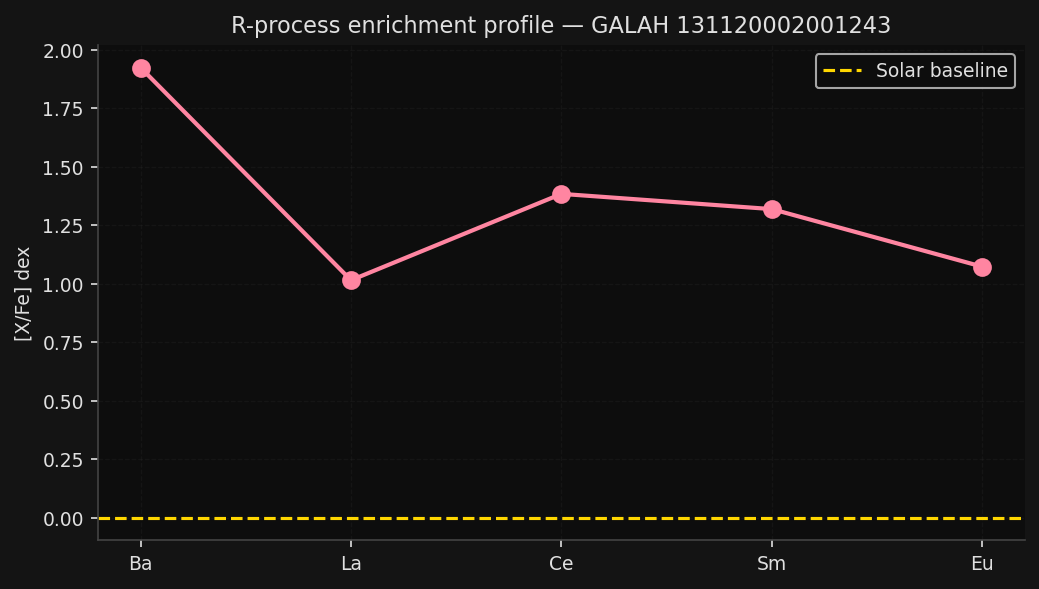

In [82]:
elements = ['[Sr/Fe]','[Ba/Fe]','[La/Fe]','[Ce/Fe]','[Sm/Fe]','[Eu/Fe]']
labels = ['Sr','Ba','La','Ce','Sm','Eu']

vals = [star[el] for el in elements]

plt.figure()
plt.plot(labels, vals, 'o-', linewidth=2, markersize=8)
plt.axhline(0, color = "#ffd700",linestyle='--', label='Solar baseline')
plt.ylabel('[X/Fe] dex')
plt.title(f"R-process enrichment profile — GALAH 131120002001243")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/rprocess_profile.png', dpi=150)
plt.show()


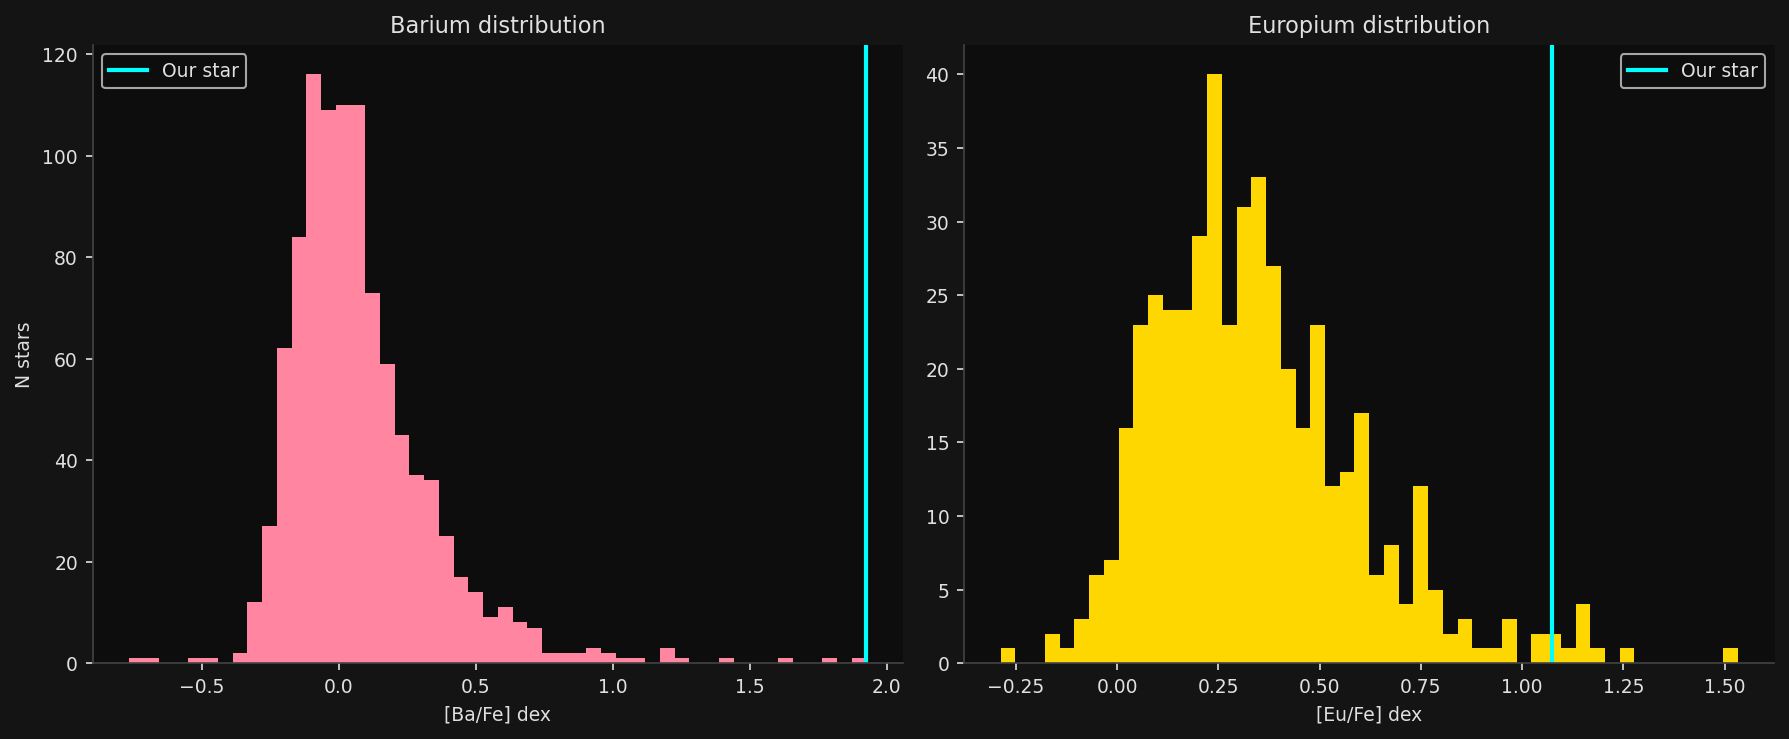

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['[Ba/Fe]'].dropna(), bins=50)
axes[0].axvline(star['[Ba/Fe]'], color='cyan', linewidth=2, label='Our star')
axes[0].set_xlabel('[Ba/Fe] dex')
axes[0].set_ylabel('N stars')
axes[0].set_title('Barium distribution')
axes[0].legend()

axes[1].hist(df['[Eu/Fe]'].dropna(), bins=50,color = '#ffd700')
axes[1].axvline(star['[Eu/Fe]'], color='cyan', linewidth=2, label='Our star')
axes[1].set_xlabel('[Eu/Fe] dex')
axes[1].set_title('Europium distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/abundance_distributions.png', dpi=150)
plt.show()

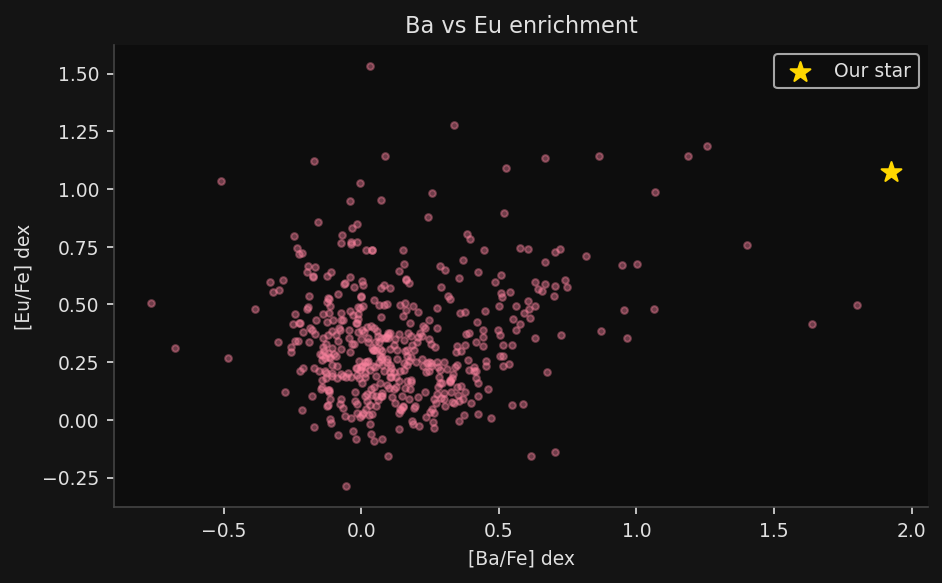

In [84]:
clean = df[['[Ba/Fe]','[Eu/Fe]']].dropna()

plt.figure()
plt.scatter(clean['[Ba/Fe]'], clean['[Eu/Fe]'], alpha=0.4, s=10)
plt.scatter(star['[Ba/Fe]'], star['[Eu/Fe]'], marker = '*',
            color='gold', s=100, zorder=5, label='Our star')
plt.xlabel('[Ba/Fe] dex')
plt.ylabel('[Eu/Fe] dex')
plt.title('Ba vs Eu enrichment')
plt.legend()
plt.savefig('plots/ba_eu_correlation.png', dpi=150)
plt.show()

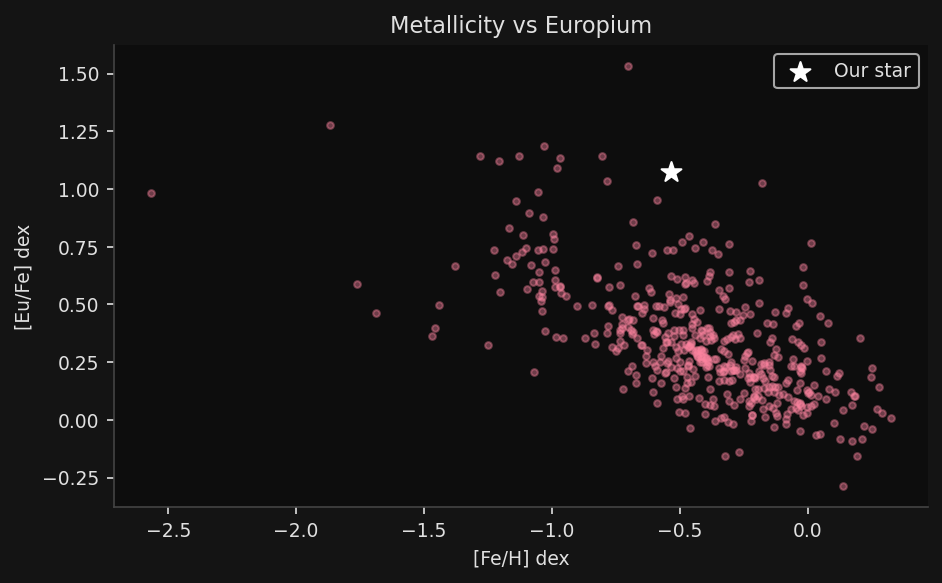

In [85]:
plt.figure()
plt.scatter(df['[Fe/H]'], df['[Eu/Fe]'], alpha=0.4, s=10)
plt.scatter(star['[Fe/H]'], star['[Eu/Fe]'],
            color='white', s=100, zorder=5, label='Our star',marker = '*')
plt.xlabel('[Fe/H] dex')
plt.ylabel('[Eu/Fe] dex')
plt.title('Metallicity vs Europium')
plt.legend()
plt.savefig('plots/feh_eu.png', dpi=150)
plt.show()

In [86]:
# Find stars within 10 degrees on sky of our star
from astropy.coordinates import SkyCoord
import astropy.units as u

our_coord = SkyCoord(ra=star['RA_ICRS']*u.deg, 
                     dec=star['DE_ICRS']*u.deg)

all_coords = SkyCoord(ra=df['RA_ICRS'].values*u.deg,
                      dec=df['DE_ICRS'].values*u.deg)

separations = our_coord.separation(all_coords)
df['separation_deg'] = separations.deg

neighbours = df[df['separation_deg'] < 10].copy()
print(f"Stars within 10 degrees: {len(neighbours)}")
print(neighbours[['GALAH','[Fe/H]','[Ba/Fe]','[Eu/Fe]','separation_deg']].sort_values('separation_deg'))

Stars within 10 degrees: 43
               GALAH    [Fe/H]   [Ba/Fe]   [Eu/Fe]  separation_deg
645  131120002001243 -0.535506  1.924992  1.073567        0.000000
643  131120002001213 -0.663354 -0.167953       NaN        0.111398
922  131123002002259 -0.958970  0.632099  0.354699        0.187634
649  131120002001285 -0.687906 -0.036101       NaN        0.191733
644  131120002001220 -1.280307  0.864749  1.143630        0.197900
646  131120002001246 -1.056942  1.065831  0.986175        0.206877
642  131120002001209 -0.968835  0.668947  1.134667        0.213779
650  131120002001293 -0.363558 -0.017339  0.849310        0.217272
641  131120002001196 -1.033607  0.723723  0.737877        0.220218
639  131120002001182 -0.986827  0.304250  0.648824        0.235107
923  131123002002267 -1.102682  0.574932  0.745758        0.236323
647  131120002001276 -1.037258  0.243582  0.876935        0.238398
648  131120002001282 -1.127594  1.188269  1.142765        0.238634
921  131123002002188 -0.988256  0.

In [87]:
rich = neighbours[
    (neighbours['[Eu/Fe]'] > 0.8) 
].copy()

print(f"High-Eu neighbours: {len(rich)}")
print(rich[['GALAH','[Fe/H]','[Ba/Fe]','[Eu/Fe]',
            'separation_deg']].sort_values('[Eu/Fe]', ascending=False))

High-Eu neighbours: 10
               GALAH    [Fe/H]   [Ba/Fe]   [Eu/Fe]  separation_deg
637  131120002001173 -1.032022  1.254635  1.184404        0.276508
644  131120002001220 -1.280307  0.864749  1.143630        0.197900
648  131120002001282 -1.127594  1.188269  1.142765        0.238634
642  131120002001209 -0.968835  0.668947  1.134667        0.213779
636  131120002001160 -0.981558  0.526497  1.088996        0.281455
645  131120002001243 -0.535506  1.924992  1.073567        0.000000
646  131120002001246 -1.056942  1.065831  0.986175        0.206877
647  131120002001276 -1.037258  0.243582  0.876935        0.238398
650  131120002001293 -0.363558 -0.017339  0.849310        0.217272
635  131120002001145 -0.998224  0.384749  0.806972        0.303983


In [88]:
# better filter: look for iron content same to our star

same_age = neighbours[
    (neighbours['[Eu/Fe]'] > 0.8) &
    (neighbours['[Fe/H]'].between(-0.7, -0.3))
].copy()

print(f"Same age, high-Eu neighbours: {len(same_age)}")
print(same_age[['GALAH','[Fe/H]','[Ba/Fe]','[Eu/Fe]',
                'separation_deg']].sort_values('[Eu/Fe]', ascending=False))

Same age, high-Eu neighbours: 2
               GALAH    [Fe/H]   [Ba/Fe]   [Eu/Fe]  separation_deg
645  131120002001243 -0.535506  1.924992  1.073567        0.000000
650  131120002001293 -0.363558 -0.017339  0.849310        0.217272


In [89]:
pair = same_age[same_age['GALAH'] != star['GALAH']].iloc[0]

elements = ['[Ba/Fe]','[Eu/Fe]','[La/Fe]','[Ce/Fe]','[Sm/Fe]']

print(f"{'Element':<12} {'Our star (dex)':<5} {'Our star (x solar)':<9} {'Neighbour (dex)':<9} {'Neighbour (x solar)':>21}")
print("-" * 90)

for el in elements:
    v1 = star[el]
    v2 = pair[el]
    v1_str = f"{v1:.2f}         {10**v1:.1f}x" if pd.notna(v1) else "NaN"
    v2_str = f"{v2:.2f}         {10**v2:.1f}x" if pd.notna(v2) else "NaN"
    print(f"{el:<12} {v1_str:>25} {v2_str:>30}")

Element      Our star (dex) Our star (x solar) Neighbour (dex)   Neighbour (x solar)
------------------------------------------------------------------------------------------
[Ba/Fe]             1.92         84.1x             -0.02         1.0x
[Eu/Fe]             1.07         11.8x              0.85         7.1x
[La/Fe]             1.02         10.4x             1.24         17.5x
[Ce/Fe]             1.38         24.3x             1.47         29.3x
[Sm/Fe]             1.32         20.9x             1.54         34.7x


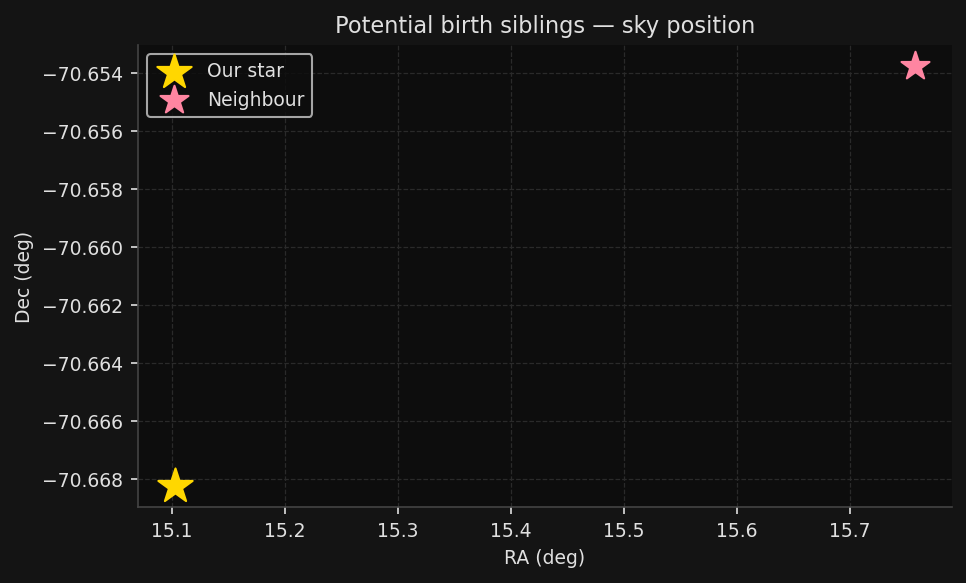

In [90]:
plt.figure()
for _, row in same_age.iterrows():
    is_ours = row['GALAH'] == star['GALAH']
    plt.scatter(row['RA_ICRS'], row['DE_ICRS'],
                s=300 if is_ours else 200,
                marker='*',
                color='gold' if is_ours else '#FF85A1',
                zorder=5,
                label='Our star' if is_ours else 'Neighbour')

plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.title('Potential birth siblings — sky position')
plt.legend()
plt.savefig('plots/siblings_sky.png', dpi=150)
plt.grid()
plt.show()

In [91]:
neighbour_plx = pair['plx']
print(f"Neighbour parallax: {neighbour_plx:.4f} mas")
print(f"Neighbour distance: {1000/neighbour_plx:.0f} pc")
print(f"Our star distance: {1000/star['plx']:.0f} pc")

Neighbour parallax: 0.5380 mas
Neighbour distance: 1859 pc
Our star distance: 35336 pc


In [92]:
our_dist = 1000/star['plx']

df['distance_pc'] = 1000/df['plx']
df['dist_diff'] = abs(df['distance_pc'] - our_dist)

real_neighbours = df[
    (df['separation_deg'] < 10) &
    (df['dist_diff'] < 5000) &
    (df['[Eu/Fe]'] > 0.8)
].copy()

print(f"True 3D neighbours with high Eu: {len(real_neighbours)}")
print(real_neighbours[['GALAH','[Fe/H]','[Eu/Fe]','[Ba/Fe]',
                        'distance_pc','separation_deg']])

True 3D neighbours with high Eu: 1
               GALAH    [Fe/H]   [Eu/Fe]   [Ba/Fe]   distance_pc  \
645  131120002001243 -0.535506  1.073567  1.924992  35335.689046   

     separation_deg  
645             0.0  


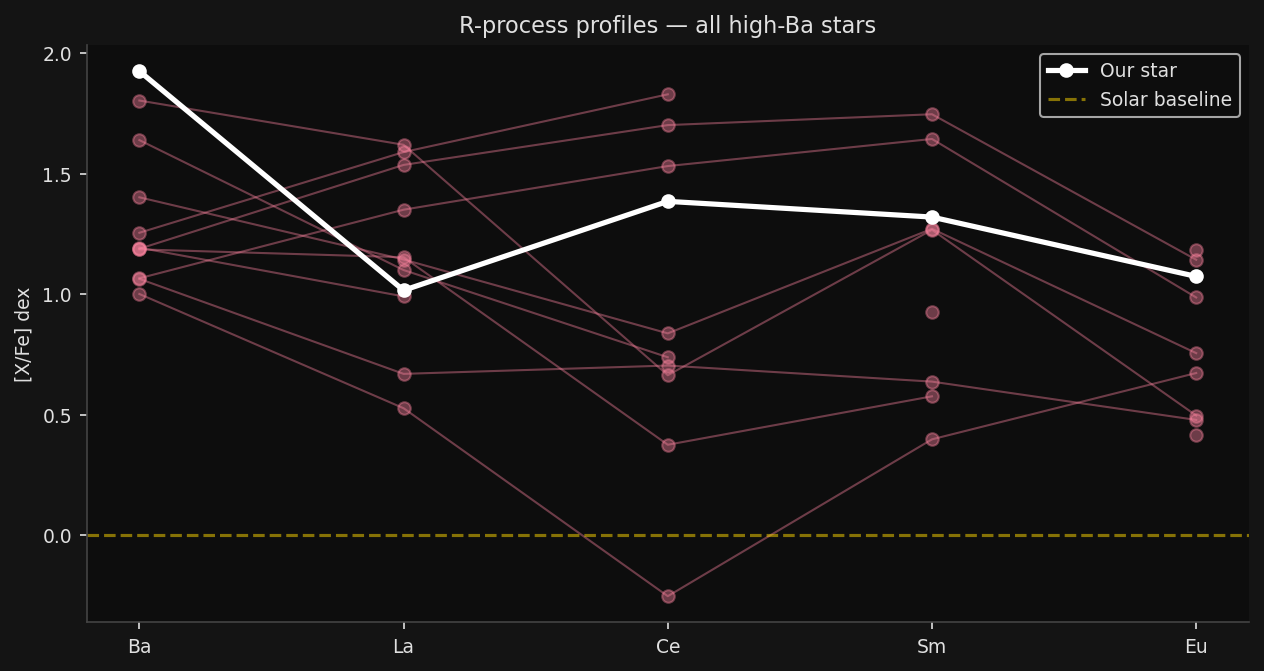

In [93]:
high_ba = df[df['[Ba/Fe]'] > 1.0].copy()
elements = ['[Ba/Fe]','[La/Fe]','[Ce/Fe]','[Sm/Fe]','[Eu/Fe]']
labels = ['Ba','La','Ce','Sm','Eu']

plt.figure(figsize=(10,5))
for _, row in high_ba.iterrows():
    vals = [row[el] for el in elements]
    is_ours = row['GALAH'] == star['GALAH']
    plt.plot(labels, vals, 
             'o-',
             linewidth=2.5 if is_ours else 1,
             alpha=1.0 if is_ours else 0.4,
             color='white' if is_ours else '#FF85A1',
             zorder=5 if is_ours else 1,
             label='Our star' if is_ours else None)

plt.axhline(0, color='#ffd700', linestyle='--', alpha=0.5, label='Solar baseline')
plt.ylabel('[X/Fe] dex')
plt.title('R-process profiles — all high-Ba stars')
plt.legend()
plt.savefig('plots/all_rprocess_profiles.png', dpi=150)
plt.show()

In [94]:
url = f"https://datacentral.org.au/vo/slink/links?ID={galah_id}&collection=galah_dr3"
response = requests.get(url)
print(response.status_code)
print(response.text[:500])

200
<VOTABLE version="1.3" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xmlns="http://www.ivoa.net/xml/VOTable/v1.3"><RESOURCE name="AAO DataCentral slink result" type="results"><INFO name="Datetime Requested" value="2026-04-17T17:42:58.954956Z" /><INFO name="QUERY_STATUS" value="ERROR">UsageFault: GET parameter collection not recognised </INFO><TABLE><FIELD name="ID" datatype="char" arraysize="*" ucd="meta.id;meta.main" /><FIELD name="access_url" datatype="char" arraysize="*" ucd="meta.ref


In [95]:
# GALAH DR3 spectra are stored by plate/fibre
# construct from the GALAH ID: YYMMDD + plate + fibre
galah_id = '131120002001243'

# parse the ID
date = galah_id[:6]    # 131120
plate = galah_id[6:9]  # 002
fibre = galah_id[9:12] # 001
obs = galah_id[12:]    # 243

print(f"Date: {date}")
print(f"Plate: {plate}")
print(f"Fibre: {fibre}")
print(f"Obs: {obs}")

Date: 131120
Plate: 002
Fibre: 001
Obs: 243


In [96]:
url = f"https://datacentral.org.au/vo/slink/links?ID=galah_dr3.spectra.{date}{plate}{fibre}&collection=galah_dr3"
print(url)

# try direct fits download
fits_url = f"https://datacentral.org.au/services/fits/{date}/{plate}0{fibre}/com/{date}{plate}0{fibre}sci.fits"
print(fits_url)

response = requests.get(fits_url)

print(f"Status: {response.status_code}")


https://datacentral.org.au/vo/slink/links?ID=galah_dr3.spectra.131120002001&collection=galah_dr3
https://datacentral.org.au/services/fits/131120/0020001/com/1311200020001sci.fits
Status: 404


In [97]:
sobject_id = '131120002001243'

# Red camera — covers Ba and other r-process lines
url = f"https://datacentral.org.au/vo/slink/links?ID={sobject_id}&DR=galah_dr3&IDX=0&FILT=R&RESPONSEFORMAT=fits"

response = requests.get(url)
print(f"Status: {response.status_code}")

# Save the fits file
with open('star_spectrum_red.fits', 'wb') as f:
    f.write(response.content)
print("Saved.")

Status: 200
Saved.


In [98]:
from astropy.io import fits

hdul = fits.open('star_spectrum_red.fits')
hdul.info()

Filename: star_spectrum_red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      36   (4096,)   float64   


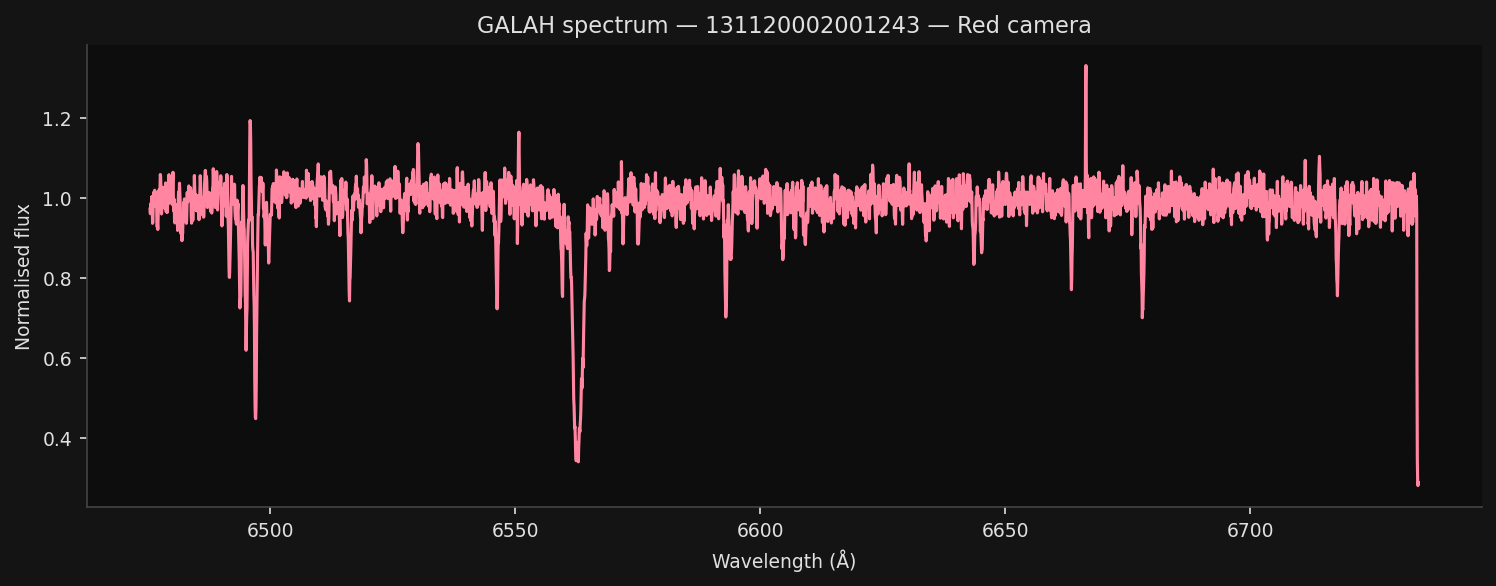

Wavelength range: 6475.4 to 6734.3 Å


In [99]:
flux = hdul[0].data
header = hdul[0].header

# construct wavelength array from header
crval = header['CRVAL1']  # starting wavelength
cdelt = header['CDELT1']  # wavelength per pixel
wavelength = crval + cdelt * np.arange(len(flux))

plt.figure(figsize=(12,4))
plt.plot(wavelength, flux)
plt.xlabel('Wavelength (Å)')
plt.ylabel('Normalised flux')
plt.title(f'GALAH spectrum — {sobject_id} — Red camera')
plt.savefig('plots/spectrum_red.png', dpi=150)
plt.show()

print(f"Wavelength range: {wavelength[0]:.1f} to {wavelength[-1]:.1f} Å")

Status: 200


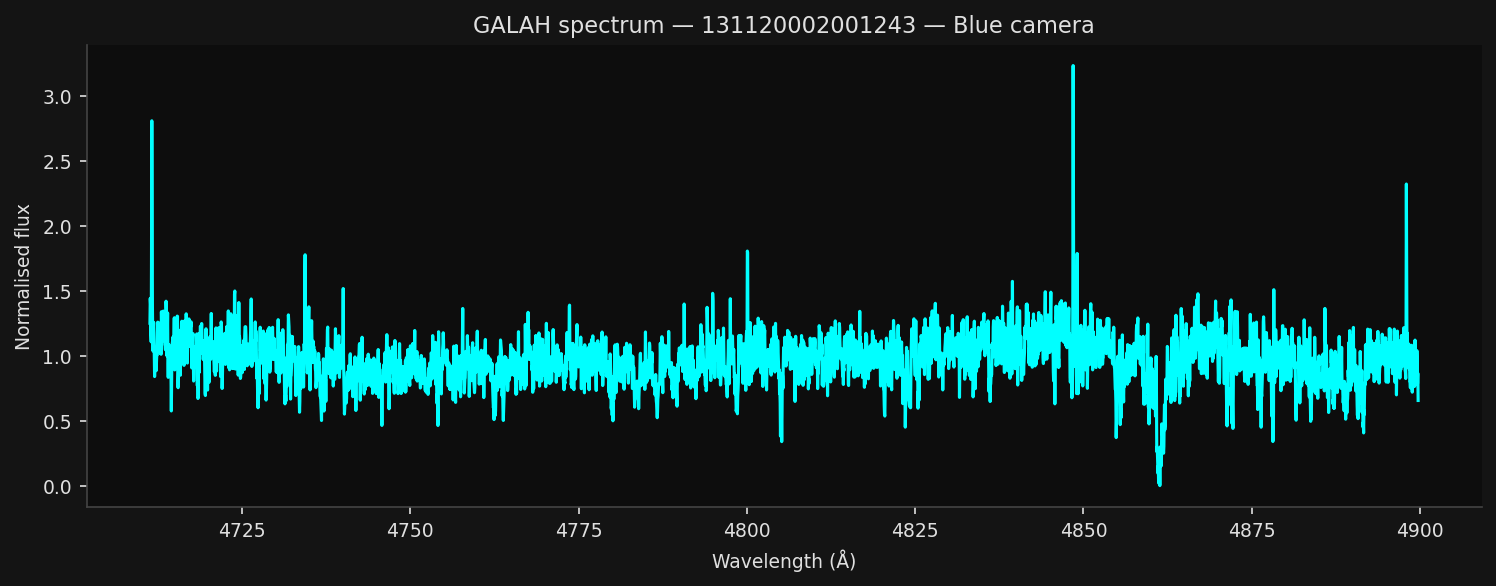

Wavelength range: 4711.3 to 4899.7 Å


In [100]:
url_blue = f"https://datacentral.org.au/vo/slink/links?ID={sobject_id}&DR=galah_dr3&IDX=0&FILT=B&RESPONSEFORMAT=fits"

response_b = requests.get(url_blue)
print(f"Status: {response_b.status_code}")

with open('star_spectrum_blue.fits', 'wb') as f:
    f.write(response_b.content)

hdul_b = fits.open('star_spectrum_blue.fits')
flux_b = hdul_b[0].data
header_b = hdul_b[0].header

crval_b = header_b['CRVAL1']
cdelt_b = header_b['CDELT1']
wavelength_b = crval_b + cdelt_b * np.arange(len(flux_b))

plt.figure(figsize=(12,4))
plt.plot(wavelength_b, flux_b, color = "cyan")
plt.xlabel('Wavelength (Å)')
plt.ylabel('Normalised flux')
plt.title(f'GALAH spectrum — {sobject_id} — Blue camera')
plt.savefig('plots/spectrum_blue.png', dpi=150)
plt.show()

print(f"Wavelength range: {wavelength_b[0]:.1f} to {wavelength_b[-1]:.1f} Å")

Status: 200


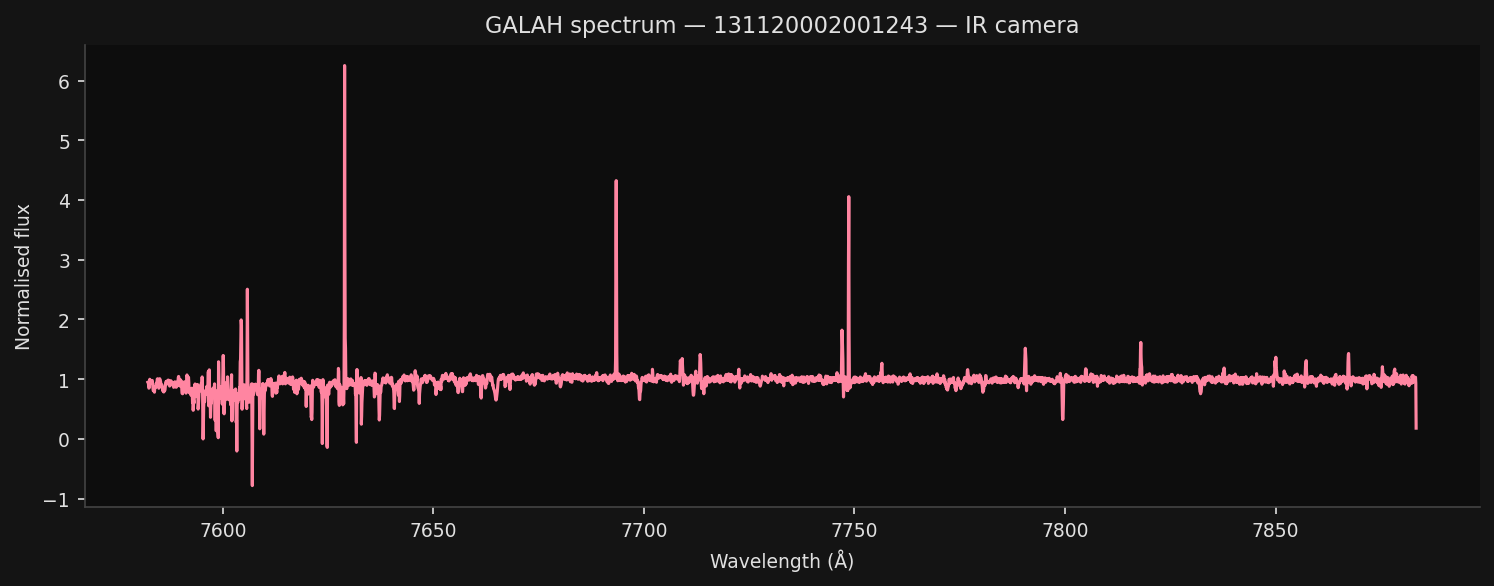

Wavelength range: 7582.2 to 7883.4 Å


In [101]:
url_ir = f"https://datacentral.org.au/vo/slink/links?ID={sobject_id}&DR=galah_dr3&IDX=0&FILT=I&RESPONSEFORMAT=fits"

response_i = requests.get(url_ir)
print(f"Status: {response_i.status_code}")

with open('star_spectrum_ir.fits', 'wb') as f:
    f.write(response_i.content)

hdul_i = fits.open('star_spectrum_ir.fits')
flux_i = hdul_i[0].data
header_i = hdul_i[0].header

crval_i = header_i['CRVAL1']
cdelt_i = header_i['CDELT1']
wavelength_i = crval_i + cdelt_i * np.arange(len(flux_i))

plt.figure(figsize=(12,4))
plt.plot(wavelength_i, flux_i)
plt.xlabel('Wavelength (Å)')
plt.ylabel('Normalised flux')
plt.title(f'GALAH spectrum — {sobject_id} — IR camera')
plt.savefig('plots/spectrum_ir.png', dpi=150)
plt.show()

print(f"Wavelength range: {wavelength_i[0]:.1f} to {wavelength_i[-1]:.1f} Å")

In [102]:
# Try with different IDX parameter
url_green2 = f"https://datacentral.org.au/vo/slink/links?ID={sobject_id}&DR=galah_dr3&IDX=1&FILT=G&RESPONSEFORMAT=fits"

response_g2 = requests.get(url_green2)
print(f"Status: {response_g2.status_code}")
print(response_g2.content[:200])

Status: 500
b'\n\n\n<!DOCTYPE html>\n<html lang="en">\n<head>\n    \n        \n            <meta http-equiv="Content-Type" content="text/html; charset=utf-8"/>\n<meta http-equiv="X-UA-Compatible" content="IE=edge">\n<meta na'
